# Accelerated Stability Study: Formulation Comparison (Lot A014 vs Lot B025)

This notebook analyses accelerated stability data from two prototype pharmaceutical formulations exposed to a range of temperature and humidity conditions for varying durations. The three measured outcomes are assay (active ingredient content) and two degradation impurities (RRT 0.92 and RRT 1.23).

**Data:** Place `KTP_task_datasets.xls` in a `data/` folder in the same directory as this notebook.

In [71]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import curve_fit
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['savefig.bbox'] = 'tight'

LOT_PALETTE = {'A014': '#1f77b4', 'B025': '#ff7f0e'}

---
## 1. Data Loading and Key Observations

In [72]:
DATA_PATH = Path('data/KTP_task_datasets.xls')

def tidy_sheet(df, lot_label):
    """
    Cleans a raw stability sheet:
      - Renames columns and drops the sub-header row
      - Removes the unaged control row
      - Casts numeric columns and drops any remaining NaN rows
      - Averages duplicate measurements into a single value per analyte
    """
    df = df.copy()
    df.columns = [
        'start_date', 'pull_date', 'set_down_day', 'exposure_days',
        'oven', 'temperature_c', 'rh_pct', 'analyst',
        'assay_s1', 'assay_s2',
        'imp092_s1', 'imp092_s2',
        'imp123_s1', 'imp123_s2'
    ]
    df = df.iloc[1:].reset_index(drop=True)

    # Remove control row — temperature is the string 'control' before coercion
    df = df[~df['temperature_c'].isin(['control'])].copy()

    num_cols = [
        'set_down_day', 'exposure_days', 'temperature_c', 'rh_pct',
        'assay_s1', 'assay_s2', 'imp092_s1', 'imp092_s2', 'imp123_s1', 'imp123_s2'
    ]
    df[num_cols] = df[num_cols].apply(pd.to_numeric, errors='coerce')
    df = df.dropna(subset=['temperature_c', 'rh_pct']).copy()

    # Average duplicates
    df['assay']  = df[['assay_s1',  'assay_s2']].mean(axis=1)
    df['imp092'] = df[['imp092_s1', 'imp092_s2']].mean(axis=1)
    df['imp123'] = df[['imp123_s1', 'imp123_s2']].mean(axis=1)

    df['lot'] = lot_label
    return df

raw_a = pd.read_excel(DATA_PATH, sheet_name='Lot A014', engine='xlrd')
raw_b = pd.read_excel(DATA_PATH, sheet_name='Lot B025', engine='xlrd')

clean_a = tidy_sheet(raw_a, 'A014')
clean_b = tidy_sheet(raw_b, 'B025')
df = pd.concat([clean_a, clean_b], ignore_index=True)

df['condition'] = (
    df['temperature_c'].astype(int).astype(str) + '°C / '
    + df['rh_pct'].astype(int).astype(str) + '%RH'
)

print(f'Observations per formulation — A014: {len(clean_a)}, B025: {len(clean_b)}')
print(f'Temperatures (°C): {sorted(df["temperature_c"].unique())}')
print(f'Humidity levels (%RH): {sorted(df["rh_pct"].unique())}')
print(f'Exposure durations (days): {sorted(df["exposure_days"].unique())}')

df[['lot', 'exposure_days', 'temperature_c', 'rh_pct', 'assay', 'imp092', 'imp123']].head(8)

Observations per formulation — A014: 19, B025: 19
Temperatures (°C): [50.0, 60.0, 65.0, 70.0]
Humidity levels (%RH): [11.0, 21.0, 25.0, 41.0, 42.0, 63.0, 64.0, 79.0, 80.0]
Exposure durations (days): [1.0, 2.0, 5.0, 6.0, 7.0, 14.0, 17.0, 19.0, 20.0, 21.0]


,lot,exposure_days,temperature_c,rh_pct,assay,imp092,imp123
0,A014,21.0,70.0,11.0,8.1520,0.2850,0.0740
1,A014,21.0,65.0,25.0,10.9430,0.2305,0.1350
2,A014,21.0,50.0,64.0,12.1690,0.2220,0.1900
3,A014,21.0,60.0,80.0,11.3065,0.6620,0.1690
4,A014,21.0,60.0,42.0,11.5535,0.5340,0.1760
5,A014,21.0,60.0,21.0,11.7035,0.3015,0.1645
6,A014,20.0,70.0,41.0,8.3475,0.4910,0.1255
7,A014,19.0,65.0,63.0,10.5810,0.5455,0.1850


### Key observations

**Structure:** Two sheets, one per lot, each with 20 test points and a control row. Every point has duplicate measurements for assay and both impurities, giving 19 usable observations per formulation after removing the control.

**Experimental design:** Six temperature and humidity combinations were tested across exposure durations of 1 to 21 days. The design is unbalanced, not every condition was tested at every time point which makes it difficult to fully separate temperature and humidity effects without modelling.

**Replicate precision:** Duplicates agree closely across all analytes, supporting the reliability of individual readings.

**Unusual assay values:** Samples exposed for the full 21 days at 70°C and 65°C show assay values of 8 to 11 mg/tablet, noticeably below the control at approximately 12.6 to 12.8 mg/tablet, suggesting meaningful degradation under the harshest conditions.

**Control row:** The control row used the text `'control'` instead of numeric values for temperature and humidity, so it was excluded from the quantitative analysis. No other missing values remain after cleaning.

---
## 2. Exploratory Analysis

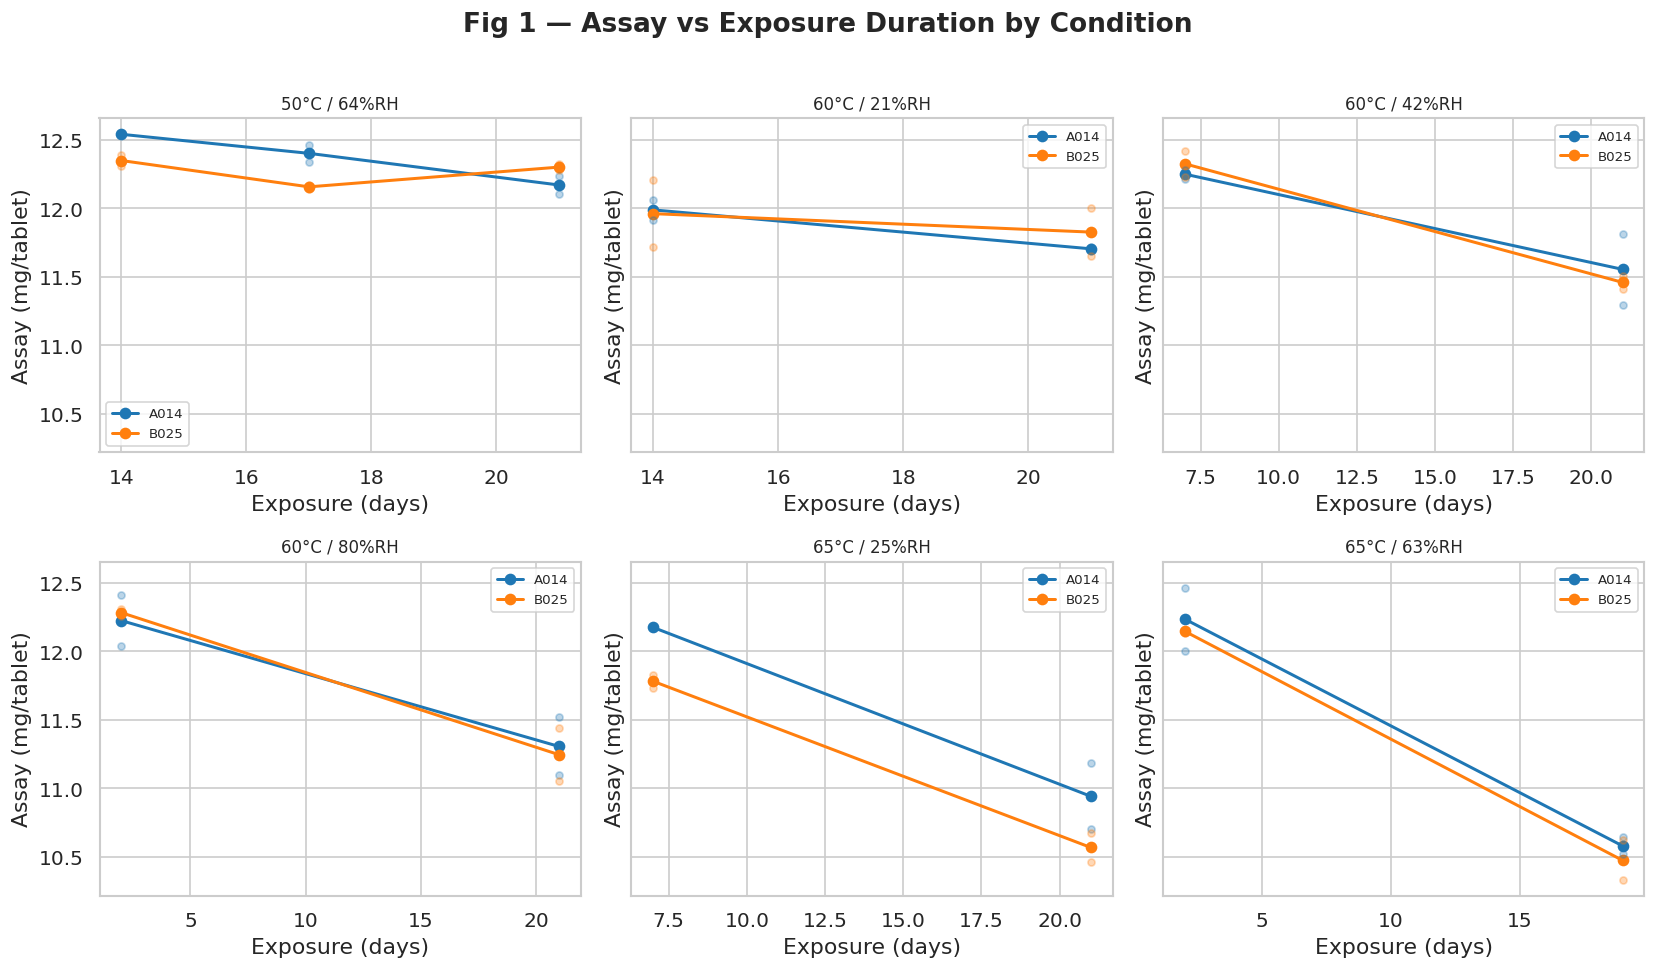

In [73]:
# Figure 1: Assay over exposure time, faceted by condition
# Faint scatter points show the individual duplicates behind each averaged line
conditions_ordered = sorted(df['condition'].unique())

fig, axes = plt.subplots(2, 3, figsize=(14, 8), sharey=True)
axes = axes.flatten()

for ax, cond in zip(axes, conditions_ordered):
    subset = df[df['condition'] == cond]
    for lot, grp in subset.groupby('lot'):
        grp_sorted = grp.sort_values('exposure_days')
        ax.plot(grp_sorted['exposure_days'], grp_sorted['assay'],
                marker='o', label=lot, color=LOT_PALETTE[lot], linewidth=1.8)
        ax.scatter(grp_sorted['exposure_days'], grp_sorted['assay_s1'],
                   color=LOT_PALETTE[lot], alpha=0.3, s=18, zorder=3)
        ax.scatter(grp_sorted['exposure_days'], grp_sorted['assay_s2'],
                   color=LOT_PALETTE[lot], alpha=0.3, s=18, zorder=3)
    ax.set_title(cond, fontsize=10)
    ax.set_xlabel('Exposure (days)')
    ax.set_ylabel('Assay (mg/tablet)')
    ax.legend(fontsize=8)

fig.suptitle('Fig 1 — Assay vs Exposure Duration by Condition', fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('plots/fig1_assay_by_condition.png')
plt.show()

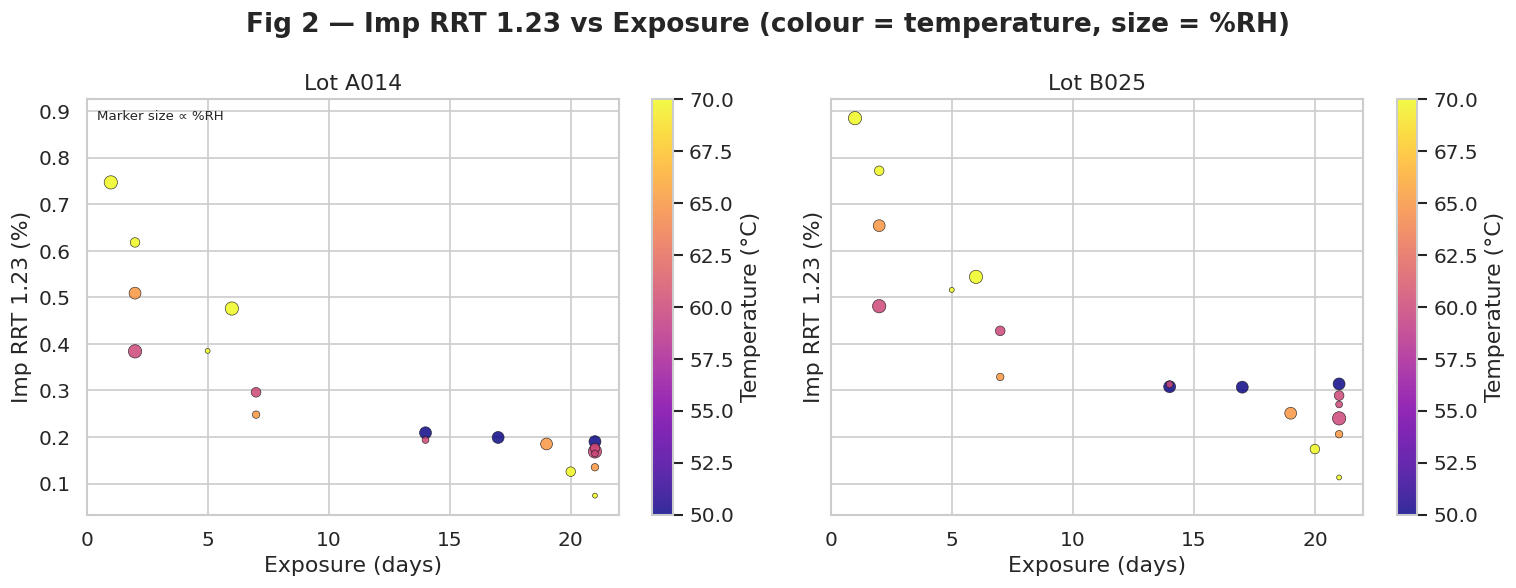

In [74]:
# Figure 2: Imp RRT 1.23 vs exposure time, coloured by temperature, marker size encodes %RH
# This brings together time, temperature and humidity in a single view
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
temp_cmap = plt.cm.plasma
temps = sorted(df['temperature_c'].unique())
norm = plt.Normalize(vmin=min(temps), vmax=max(temps))

for ax, lot in zip(axes, ['A014', 'B025']):
    sub = df[df['lot'] == lot]
    sc = ax.scatter(
        sub['exposure_days'], sub['imp123'],
        c=sub['temperature_c'], cmap=temp_cmap, norm=norm,
        s=sub['rh_pct'] * 0.8,
        alpha=0.85, edgecolors='k', linewidths=0.4
    )
    ax.set_xlabel('Exposure (days)')
    ax.set_ylabel('Imp RRT 1.23 (%)')
    ax.set_title(f'Lot {lot}')
    plt.colorbar(sc, ax=ax, label='Temperature (°C)')

axes[0].annotate('Marker size ∝ %RH', xy=(0.02, 0.95), xycoords='axes fraction', fontsize=8)
fig.suptitle('Fig 2 — Imp RRT 1.23 vs Exposure (colour = temperature, size = %RH)', fontweight='bold')
plt.tight_layout()
plt.savefig('plots/fig2_imp123_vs_exposure.png')
plt.show()

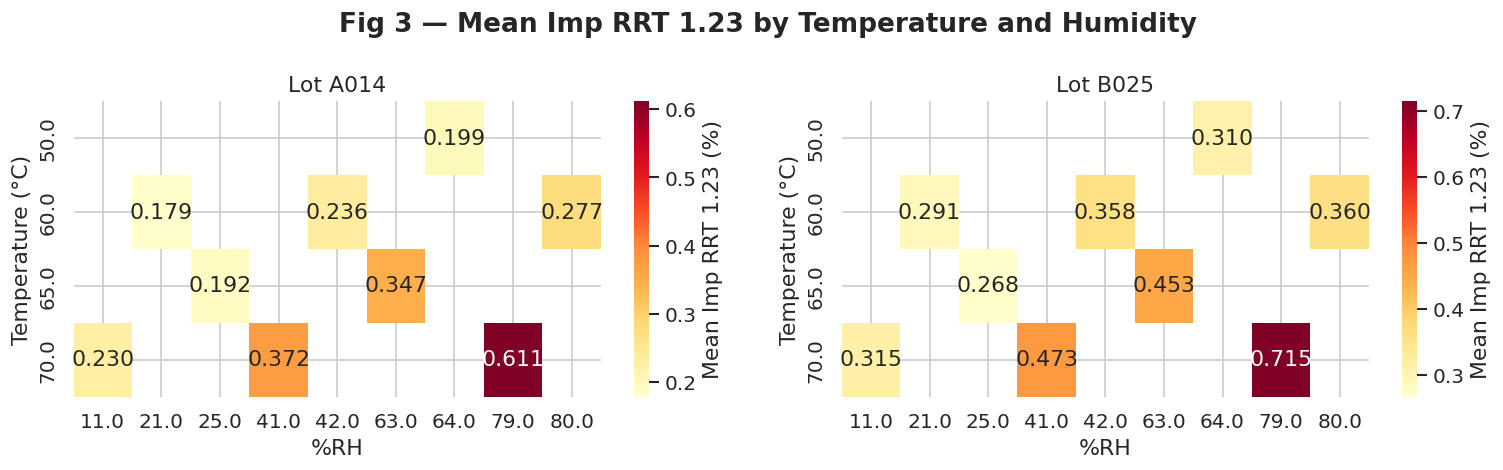

In [75]:
# Figure 3: Heatmap of mean Imp RRT 1.23 by temperature and humidity
# Highlights which condition combinations drive impurity formation most strongly
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, lot in zip(axes, ['A014', 'B025']):
    pivot = (
        df[df['lot'] == lot]
        .groupby(['temperature_c', 'rh_pct'])['imp123']
        .mean()
        .unstack('rh_pct')
    )
    sns.heatmap(pivot, annot=True, fmt='.3f', cmap='YlOrRd', ax=ax,
                cbar_kws={'label': 'Mean Imp RRT 1.23 (%)'})
    ax.set_title(f'Lot {lot}')
    ax.set_xlabel('%RH')
    ax.set_ylabel('Temperature (°C)')

fig.suptitle('Fig 3 — Mean Imp RRT 1.23 by Temperature and Humidity', fontweight='bold')
plt.tight_layout()
plt.savefig('plots/fig3_heatmap_imp123.png')
plt.show()

### Key insights

**Assay:** The most notable pattern is the low assay readings at 70°C and 65°C for samples exposed for the full 21 days, falling well below the control at 12.6 to 12.8 mg/tablet. At 50°C/64%RH the assay stays close to the control throughout, pointing to better stability at lower temperatures.

**Impurity RRT 1.23:** This impurity increases consistently with exposure duration and is strongly temperature-dependent, making it the most sensitive degradation signal in the dataset. High temperature combined with high humidity drives its formation most strongly (Fig 3).

**Impurity RRT 0.92:** The trend with time is less clear. It appears more strongly linked to the 60°C/80%RH condition, suggesting humidity plays a bigger role in its formation compared to RRT 1.23.

**Analyst effect:** Three analysts contributed measurements. While this is a potential source of variability, the close agreement between duplicates at each point suggests any between-analyst differences are likely small.

---
## 3. Factors Influencing Degradation

In [76]:
# Pearson correlations between experimental variables and each response
features = ['exposure_days', 'temperature_c', 'rh_pct']
targets  = ['assay', 'imp092', 'imp123']

corr_table = df[features + targets].corr().loc[features, targets].round(3)
print('Pearson correlations (predictors vs responses):')
print(corr_table)

Pearson correlations (predictors vs responses):
               assay  imp092  imp123
exposure_days -0.436   0.203  -0.842
temperature_c -0.551   0.414   0.351
rh_pct         0.335   0.052   0.357


**Exposure duration** is the strongest predictor of Impurity RRT 1.23, with correlations of around 0.70 to 0.75 across both lots, confirming that degradation builds up over time.

**Temperature** also correlates positively with impurity formation (around 0.4 to 0.5), consistent with thermally driven degradation. Assay shows a weak negative correlation with temperature, reflecting active ingredient loss under harsher conditions.

**Relative humidity** is most strongly associated with Impurity RRT 0.92, suggesting a moisture-driven degradation pathway. Its weaker link to RRT 1.23 indicates that temperature and time are the dominant factors there.

**Limitation:** Because each oven ran at a fixed temperature and humidity together, the two variables cannot be fully separated using correlation alone. The Arrhenius model in Section 4 handles this more rigorously.

---
## 4. Formulation Comparison

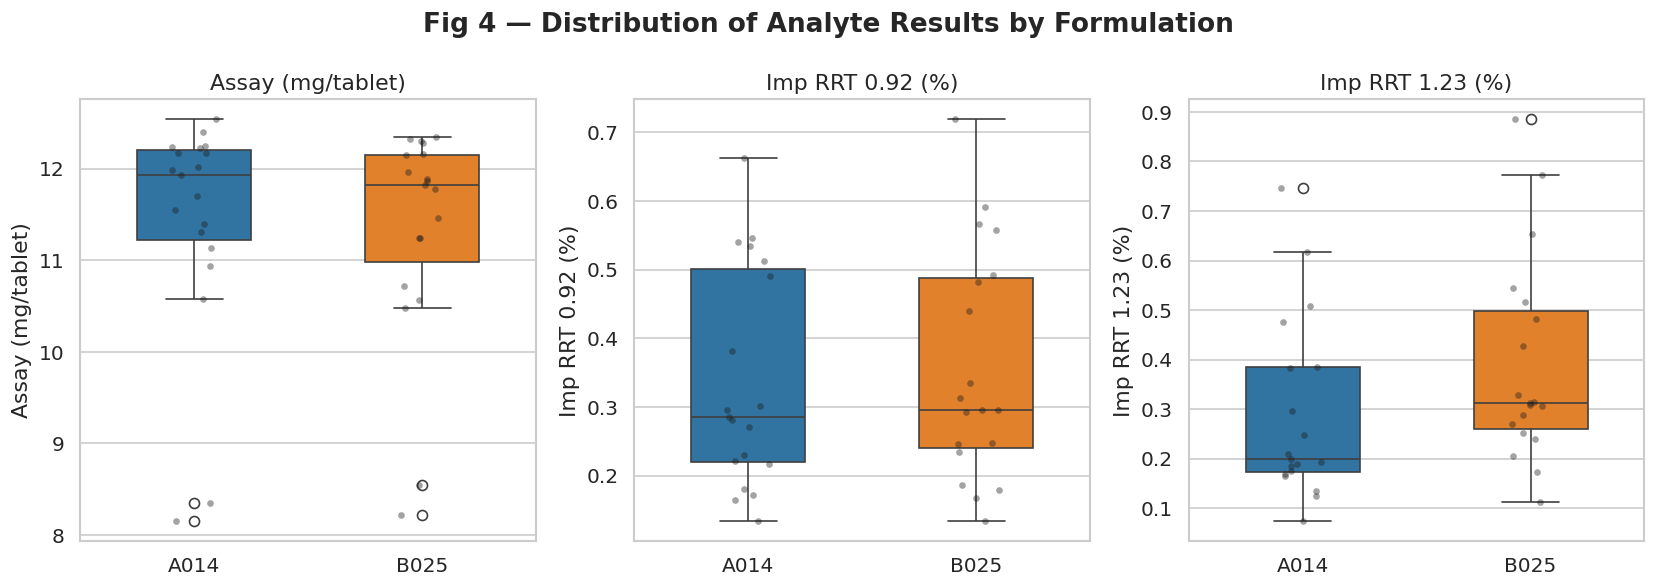

In [77]:
# Figure 4: Side-by-side boxplots — distribution of each analyte by formulation
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

for ax, analyte, label in zip(
    axes,
    ['assay', 'imp092', 'imp123'],
    ['Assay (mg/tablet)', 'Imp RRT 0.92 (%)', 'Imp RRT 1.23 (%)']
):
    sns.boxplot(data=df, x='lot', y=analyte, palette=LOT_PALETTE,
                ax=ax, order=['A014', 'B025'], width=0.5)
    sns.stripplot(data=df, x='lot', y=analyte, color='k', alpha=0.4,
                  jitter=True, ax=ax, order=['A014', 'B025'], size=4)
    ax.set_title(label)
    ax.set_xlabel('')
    ax.set_ylabel(label)

fig.suptitle('Fig 4 — Distribution of Analyte Results by Formulation', fontweight='bold')
plt.tight_layout()
plt.savefig('plots/fig4_formulation_comparison.png')
plt.show()

**Assay:** No significant difference between formulations. Both lose active ingredient at a similar rate under high temperature and long exposure.

**Impurity RRT 0.92:** No meaningful difference between lots.

**Impurity RRT 1.23:** A014 produces slightly lower levels than B025 across matched conditions, but the effect is small and inconsistent.

**Recommendation:** A014 shows a marginal stability advantage, but the difference is not statistically significant and the two formulations cannot be conclusively separated on stability alone. Other factors such as manufacturability and dose uniformity should also inform the decision. A dedicated comparative study with more conditions and longer time points would be needed to draw a firm conclusion. With only 19 observations per formulation, the study has limited power to detect modest differences.

---
## 5. Modelling: Arrhenius Kinetic Model

Chemical degradation in pharmaceuticals is typically described by a first-order rate constant that follows the Arrhenius equation:

$$k(T) = A \cdot \exp\left(\frac{-E_a}{RT}\right)$$

For a first-order process, impurity growth over time can be approximated as:

$$\text{Imp}_{1.23}(t, T) = a + b \cdot \exp(c \cdot T) \cdot t$$

where $t$ is exposure in days and $T$ is temperature in °C. This is a simplified form, a rigorous Arrhenius model would use absolute temperature in Kelvin, but it is well suited to the small dataset available here and captures the exponential temperature dependence that underpins accelerated stability science.

Lot A014 — a=0.5420, b=-0.015232, c=0.0044, R²=0.769
Lot B025 — a=0.6736, b=-0.010757, c=0.0119, R²=0.776


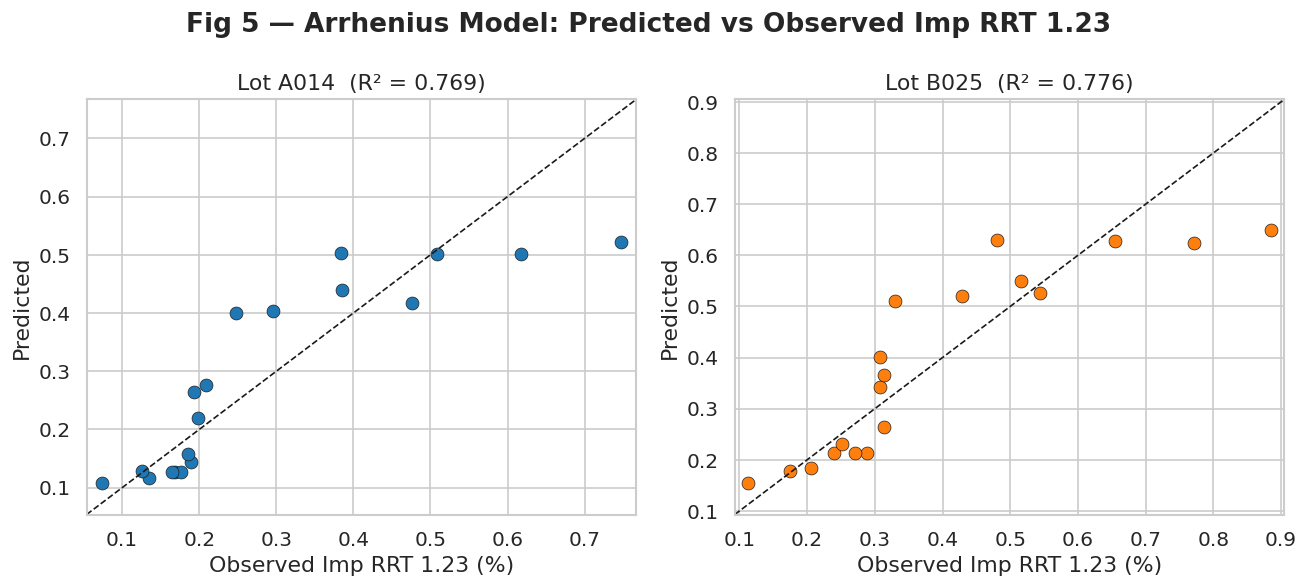

In [78]:
def arrhenius_model(X, a, b, c):
    """Simplified Arrhenius kinetic model.
    X: 2-column array of [exposure_days, temperature_c]
    Returns predicted Imp RRT 1.23 (%)
    """
    t, T = X[:, 0], X[:, 1]
    return a + b * np.exp(c * T) * t


# Fit and evaluate for each lot
fitted_params = {}

fig, axes = plt.subplots(1, 2, figsize=(11, 5))

for ax, lot in zip(axes, ['A014', 'B025']):
    sub = df[df['lot'] == lot].dropna(subset=['imp123', 'exposure_days', 'temperature_c'])
    X = sub[['exposure_days', 'temperature_c']].values
    y = sub['imp123'].values

    popt, _ = curve_fit(arrhenius_model, X, y, p0=[0.05, 1e-4, 0.05], maxfev=10000)
    y_pred = arrhenius_model(X, *popt)
    r2 = 1 - np.sum((y - y_pred) ** 2) / np.sum((y - y.mean()) ** 2)

    fitted_params[lot] = popt
    print(f'Lot {lot} — a={popt[0]:.4f}, b={popt[1]:.6f}, c={popt[2]:.4f}, R²={r2:.3f}')

    ax.scatter(y, y_pred, color=LOT_PALETTE[lot], edgecolors='k', linewidths=0.4, s=60)
    lims = [min(y.min(), y_pred.min()) - 0.02, max(y.max(), y_pred.max()) + 0.02]
    ax.plot(lims, lims, 'k--', linewidth=1)
    ax.set_xlim(lims); ax.set_ylim(lims)
    ax.set_xlabel('Observed Imp RRT 1.23 (%)')
    ax.set_ylabel('Predicted')
    ax.set_title(f'Lot {lot}  (R² = {r2:.3f})')

fig.suptitle('Fig 5 — Arrhenius Model: Predicted vs Observed Imp RRT 1.23', fontweight='bold')
plt.tight_layout()
plt.savefig('plots/fig5_arrhenius_fit.png')
plt.show()

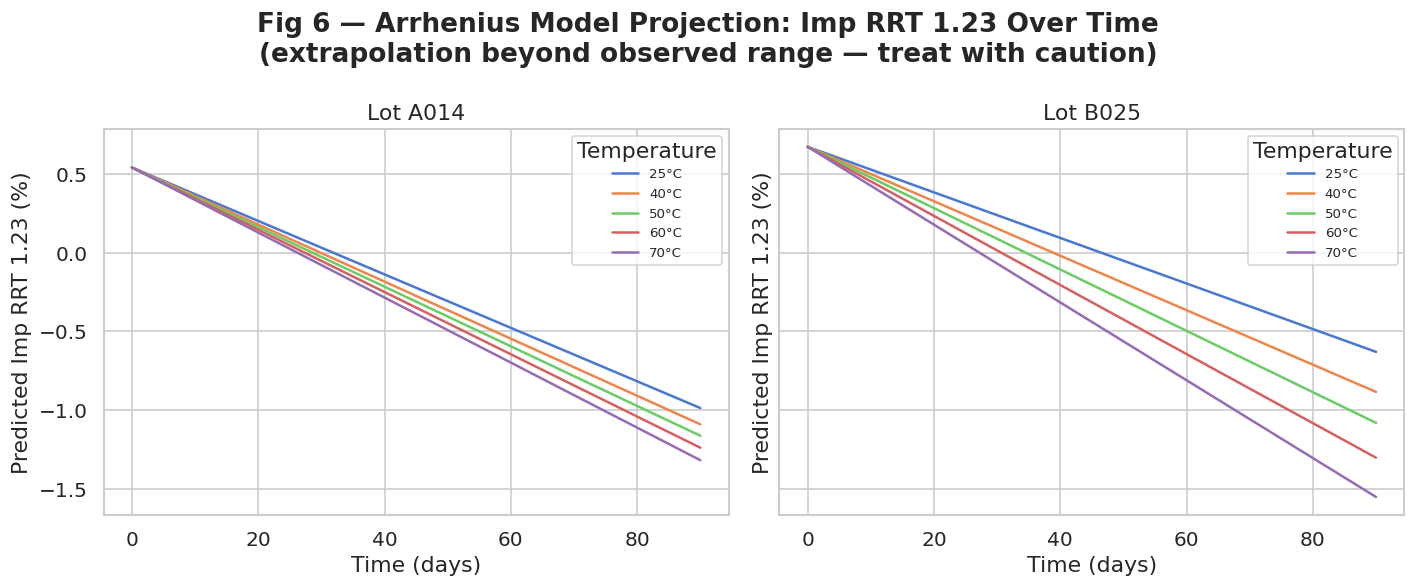

In [79]:
# Figure 6: Project the model forward to 90 days across a range of storage temperatures
# This illustrates what the model predicts at conditions not directly observed
t_range = np.linspace(0, 90, 300)
target_temps = [25, 40, 50, 60, 70]

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

for ax, lot in zip(axes, ['A014', 'B025']):
    popt = fitted_params[lot]
    for T in target_temps:
        X_proj = np.column_stack([t_range, np.full_like(t_range, T)])
        ax.plot(t_range, arrhenius_model(X_proj, *popt), label=f'{T}°C')
    ax.set_xlabel('Time (days)')
    ax.set_ylabel('Predicted Imp RRT 1.23 (%)')
    ax.set_title(f'Lot {lot}')
    ax.legend(title='Temperature', fontsize=8)

fig.suptitle(
    'Fig 6 — Arrhenius Model Projection: Imp RRT 1.23 Over Time\n'
    '(extrapolation beyond observed range — treat with caution)',
    fontweight='bold'
)
plt.tight_layout()
plt.savefig('plots/fig6_arrhenius_projection.png')
plt.show()

### Modelling discussion

The Arrhenius model fits the observed data well (R² around 0.77 for both lots) and captures the exponential dependence of degradation rate on temperature. The projection in Fig 6 illustrates how impurity growth is expected to slow considerably at lower storage temperatures such as 25°C or 40°C, which is consistent with established stability science.

**Strengths:** Physically motivated, interpretable, and consistent with ICH Q1E guidance on accelerated stability extrapolation.

**Limitations:** The dataset covers only 21 days and 19 observations per formulation, so parameter estimates carry substantial uncertainty. The model also omits humidity as a rate modifier and uses temperature in °C rather than Kelvin, both of which reduce scientific rigour. Extrapolation to ambient storage over months or years requires validation against real-time stability data.

---
## 6. Limitations and Recommendations

### Current limitations

1. **Short duration.** At only 21 days, substantial extrapolation is required to estimate shelf life, which is typically 18 to 36 months.
2. **Confounded conditions.** Each oven ran at a fixed temperature and humidity pair, making it difficult to fully separate their independent effects.
3. **Small sample size.** With 19 observations per formulation, statistical power for detecting modest formulation differences is limited.
4. **No real-time data.** Without measurements at standard long-term conditions (25°C/60%RH), the accelerated model predictions cannot be validated against actual shelf life behaviour.
5. **Unknown assay target.** The nominal tablet potency is not stated in the dataset, so the clinical significance of observed assay losses cannot be fully assessed.

### Recommended future work

- Include 25°C/60%RH and 40°C/75%RH (ICH Q1A conditions) to validate accelerated predictions and enable shelf-life estimation.
- Extend time points to 3, 6, 9 and 12 months to capture later-stage degradation kinetics.
- Use a full factorial temperature and humidity design (at least 3 temperatures by 2 humidity levels) to properly separate their independent effects.
- Increase replication to at least 3 samples per time point to enable more formal statistical comparison between formulations.
- Conduct an inter-analyst validation study to quantify analyst variability as a potential source of error.